In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("social_interaction_level_medium.csv")

In [3]:
dataset

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14.0,7.9,7.4,2.9,3.01,1.5,2.0,2.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
1,19.0,1.9,8.0,2.9,3.22,0.8,8.0,1.0,10.0,0.0,0.0,0.0,1.0,0.0,0.0
2,17.0,1.3,7.6,0.5,3.92,0.0,2.0,4.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0
3,15.0,7.4,6.9,1.6,3.48,0.8,1.0,7.0,9.0,0.0,1.0,0.0,1.0,0.0,1.0
4,15.0,4.7,4.9,3.0,2.37,1.4,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18.0,6.8,6.6,2.0,2.76,1.0,3.0,4.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0
1196,16.0,2.3,8.0,1.9,2.12,0.4,7.0,4.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0
1197,14.0,1.7,8.7,0.7,3.98,0.8,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1198,15.0,3.9,8.5,2.1,3.19,0.6,7.0,9.0,9.0,0.0,1.0,0.0,0.0,0.0,0.0


# 1.Relation between academic_performance and daily_social_media_hours.

In [4]:
dataset.corr()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
age,1.000000,-0.006635,0.001530,0.075612,-0.013973,0.011086,-0.031208,0.026363,0.038265,0.010973,0.010785,-0.022195,0.012719,0.015380,-0.058209
daily_social_media_hours,-0.006635,1.000000,-0.009472,0.035777,0.013179,0.025546,0.030698,0.027835,-0.024964,0.175201,0.011382,0.008076,-0.001914,0.001022,0.024294
sleep_hours,0.001530,-0.009472,1.000000,0.010235,0.021866,0.012701,-0.010979,-0.011879,-0.054838,-0.190630,-0.031783,-0.004883,-0.001556,0.006187,-0.021562
screen_time_before_sleep,0.075612,0.035777,0.010235,1.000000,-0.034715,-0.026450,-0.008650,-0.010344,0.028884,-0.016502,-0.026776,-0.028134,0.023590,-0.013790,-0.000437
academic_performance,-0.013973,0.013179,0.021866,-0.034715,1.000000,0.023312,-0.000600,-0.064379,0.029354,0.001441,-0.017194,0.006404,0.011781,-0.001243,0.010146
physical_activity,0.011086,0.025546,0.012701,-0.026450,0.023312,1.000000,0.012159,-0.022233,0.026200,-0.017598,0.017139,0.032109,-0.039452,-0.016611,-0.001300
stress_level,-0.031208,0.030698,-0.010979,-0.008650,-0.000600,0.012159,1.000000,0.015811,-0.000129,0.170474,0.007935,0.013169,-0.038083,-0.024161,0.009372
anxiety_level,0.026363,0.027835,-0.011879,-0.010344,-0.064379,-0.022233,0.015811,1.000000,0.031154,0.169566,-0.017236,0.008190,0.027623,-0.028329,0.012955
addiction_level,0.038265,-0.024964,-0.054838,0.028884,0.029354,0.026200,-0.000129,0.031154,1.000000,-0.013952,0.027414,0.004211,0.012593,-0.025063,0.019779
depression_label,0.010973,0.175201,-0.190630,-0.016502,0.001441,-0.017598,0.170474,0.169566,-0.013952,1.000000,-0.019836,-0.006836,0.019172,-0.019005,0.013834


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
correlation = dataset['academic_performance'].corr(dataset['daily_social_media_hours'])

In [7]:
correlation

0.013178979116841249

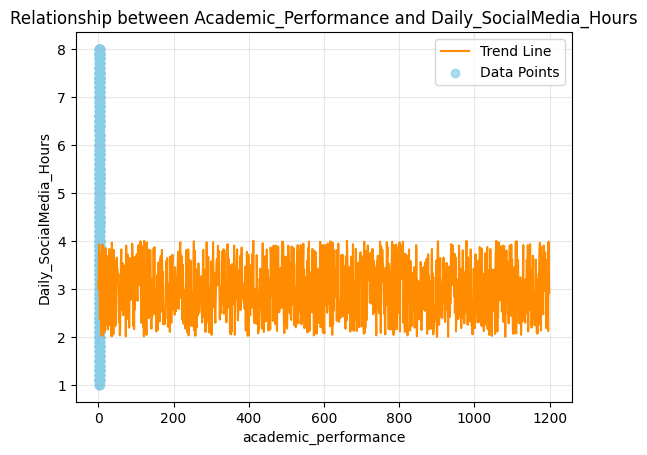

In [8]:
plt.plot(dataset['academic_performance'], color='darkorange', label=f'Trend Line')
plt.scatter(dataset['academic_performance'], dataset['daily_social_media_hours'], color='skyblue', alpha=0.7, label='Data Points')
plt.title('Relationship between Academic_Performance and Daily_SocialMedia_Hours')
plt.xlabel('academic_performance')
plt.ylabel('Daily_SocialMedia_Hours')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2.Test the similarity of the screen_time_before_sleep with respect to addiction_level and platform_usage_instagram.

In [9]:
!pip install statsmodels

In [11]:
import statsmodels.formula.api as smf
model = smf.ols('screen_time_before_sleep ~ addiction_level * platform_usage_Instagram', data=dataset).fit()
print(model.summary().tables[1])

                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                    1.7210      0.056     30.697      0.000       1.611       1.831
addiction_level                              0.0061      0.009      0.678      0.498      -0.012       0.024
platform_usage_Instagram                    -0.0633      0.097     -0.655      0.512      -0.253       0.126
addiction_level:platform_usage_Instagram     0.0037      0.015      0.240      0.811      -0.027       0.034


In [12]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
corr_matrix = dataset[['screen_time_before_sleep', 'addiction_level', 'platform_usage_Instagram']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.subplot(1, 2, 2)
sns.barplot(x='addiction_level', y='screen_time_before_sleep', hue='platform_usage_Instagram', data=dataset, palette='Set2', errorbar=None)
plt.title('Average Screen Time by Addiction Level & Instagram Use')
plt.xlabel('Addiction Level')
plt.ylabel('Avg Screen Time Before Sleep (Hours)')

plt.tight_layout()
plt.savefig('comprehensive_similarity_analysis.png', dpi=100)
plt.close()
print("Generated comprehensive_similarity_analysis.png")

Generated comprehensive_similarity_analysis.png


# 3.Parameter highly correlated with social_interaction_level_medium.

In [13]:
df_correlated = dataset.dropna(subset=['social_interaction_level_medium'])

In [14]:
df_correlated

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14.0,7.9,7.4,2.9,3.01,1.5,2.0,2.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
1,19.0,1.9,8.0,2.9,3.22,0.8,8.0,1.0,10.0,0.0,0.0,0.0,1.0,0.0,0.0
2,17.0,1.3,7.6,0.5,3.92,0.0,2.0,4.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0
3,15.0,7.4,6.9,1.6,3.48,0.8,1.0,7.0,9.0,0.0,1.0,0.0,1.0,0.0,1.0
4,15.0,4.7,4.9,3.0,2.37,1.4,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18.0,6.8,6.6,2.0,2.76,1.0,3.0,4.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0
1196,16.0,2.3,8.0,1.9,2.12,0.4,7.0,4.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0
1197,14.0,1.7,8.7,0.7,3.98,0.8,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1198,15.0,3.9,8.5,2.1,3.19,0.6,7.0,9.0,9.0,0.0,1.0,0.0,0.0,0.0,0.0


In [15]:
df_correlated.columns

Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level', 'depression_label',
       'gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok',
       'social_interaction_level_low', 'social_interaction_level_medium'],
      dtype='object')

In [16]:
numeric_cols = ['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level', 'depression_label',
       'gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok',
       'social_interaction_level_low', 'social_interaction_level_medium']
corr_matrix = df_correlated[numeric_cols].corr()

In [17]:
print("Correlation with social_interaction_level_medium:")
print(corr_matrix['social_interaction_level_medium'].sort_values(ascending=False))

Correlation with social_interaction_level_medium:
social_interaction_level_medium    1.000000
platform_usage_Instagram           0.046198
daily_social_media_hours           0.024294
gender_male                        0.020318
addiction_level                    0.019779
depression_label                   0.013834
anxiety_level                      0.012955
academic_performance               0.010146
stress_level                       0.009372
screen_time_before_sleep          -0.000437
physical_activity                 -0.001300
sleep_hours                       -0.021562
age                               -0.058209
platform_usage_TikTok             -0.078004
social_interaction_level_low      -0.529636
Name: social_interaction_level_medium, dtype: float64


In [ ]:
#Among numerical factors, platform_usage_Instagram  is the most highly correlated parameter with social_interaction_level_medium.

# 4.ANOVA Between gender_male and Physical activity at 5% significance level using hypothesis testing.

In [18]:
from scipy import stats
dataset=pd.read_csv("social_interaction_level_medium.csv")
f_stat, p_value = stats.f_oneway(dataset['gender_male'], dataset['physical_activity'])

In [19]:
print(f"F-Statistic: {f_stat}")
print(f"p-value: {p_value}")
alpha = 0.05
if p_value < alpha:
    print("Decision: Reject the Null Hypothesis. The means are significantly DIFFERENT.")
else:
    print("Decision: Fail to Reject the Null Hypothesis. The means are SIMILAR.")

F-Statistic: 513.4285648743797
p-value: 3.6630868423602433e-103
Decision: Reject the Null Hypothesis. The means are significantly DIFFERENT.


# 5.Plot the graph

C:\Anaconda 3\envs\aiml\lib\site-packages\ipykernel_launcher.py:6: UserWarning: Glyph 9 (	) missing from current font.
  
C:\Anaconda 3\envs\aiml\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 9 (	) missing from current font.
  func(*args, **kwargs)
C:\Anaconda 3\envs\aiml\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


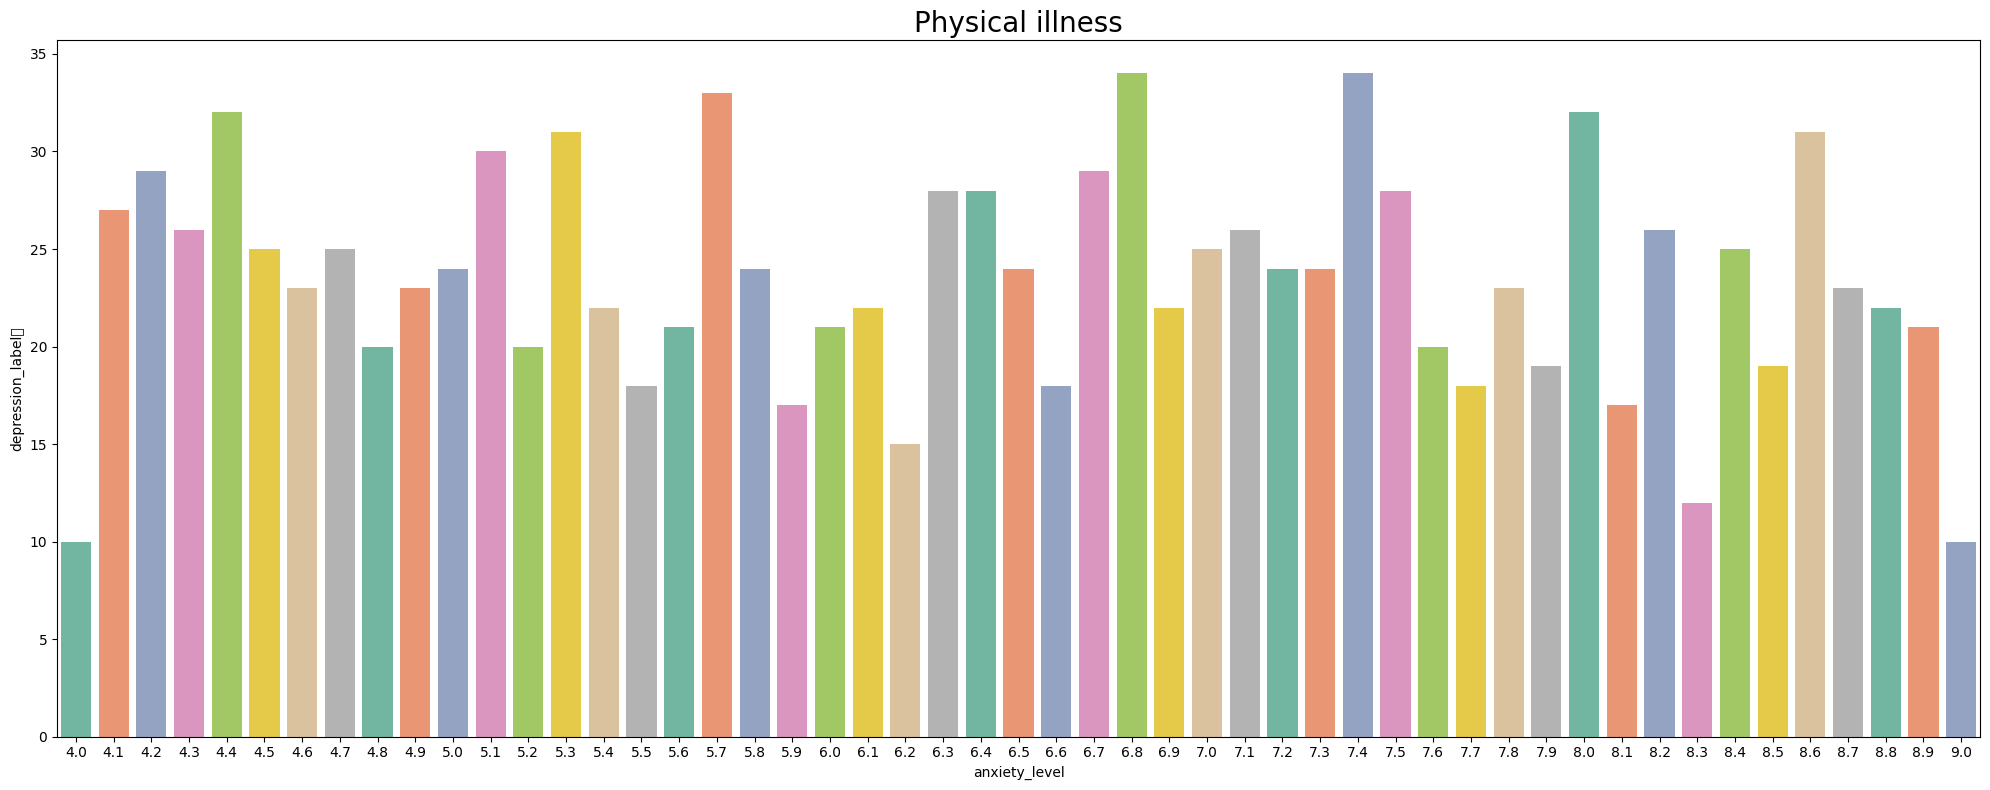

In [20]:
fig, ax = plt.subplots(figsize=(20,8)) #Setting up the plotting area (20 inches wide, 8 inches high)
sns.countplot(data=dataset, x='sleep_hours', palette='Set2', ax=ax) #Creating a simple count plot of the 'sleep_hours' column
ax.set_title('Physical illness', fontsize=20) #Adding clear labels and a title
ax.set_xlabel('anxiety_level')
ax.set_ylabel('depression_label	')
plt.tight_layout()